In [6]:
# ================================
# 1. Import Libraries
# ================================
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# ================================
# 2. Load Dataset (MNIST)
# ================================
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [8]:
# ================================
# 3. Preprocessing
# ================================
# Normalize (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN (28x28 → 28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

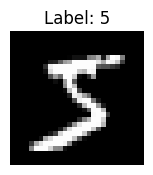

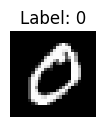

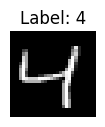

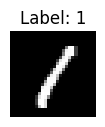

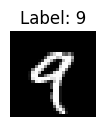

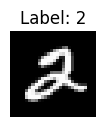

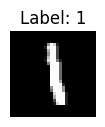

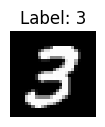

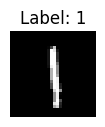

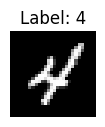

In [10]:
# ================================
# 4. Show Sample Images
# ================================
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

    plt.show()


In [11]:
# ================================
# 5. Build CNN Model
# ================================
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.Conv2D(64, (3, 3), activation='relu'),
            layers.MaxPooling2D((2, 2)),
                layers.Flatten(),
                    layers.Dense(128, activation='relu'),
                        layers.Dense(10, activation='softmax')
                        ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# ================================
# 6. Compile Model
# ================================
model.compile(
    optimizer='adam',
        loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
            )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ================================
# 7. Train Model
# ================================
history = model.fit(
    x_train,
        y_train,
            epochs=5,
                validation_data=(x_test, y_test)
                )

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 112s 59ms/step - accuracy: 0.9656 - loss: 0.1101 - val_accuracy: 0.9842 - val_loss: 0.0469
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 60ms/step - accuracy: 0.9897 - loss: 0.0344 - val_accuracy: 0.9867 - val_loss: 0.0435
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 111s 59ms/step - accuracy: 0.9932 - loss: 0.0211 - val_accuracy: 0.9892 - val_loss: 0.0355
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 59ms/step - accuracy: 0.9955 - loss: 0.0138 - val_accuracy: 0.9901 - val_loss: 0.0346
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 111s 59ms/step - accuracy: 0.9965 - loss: 0.0104 - val_accuracy: 0.9852 - val_loss: 0.0511


In [14]:
# ================================
# 8. Evaluate Model
# ================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9852 - loss: 0.0511

Test Accuracy: 0.9851999878883362


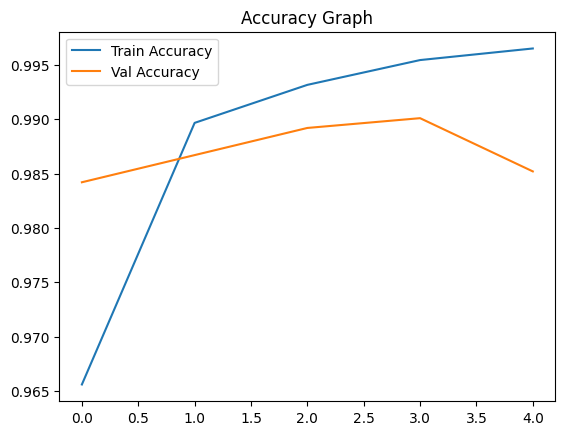

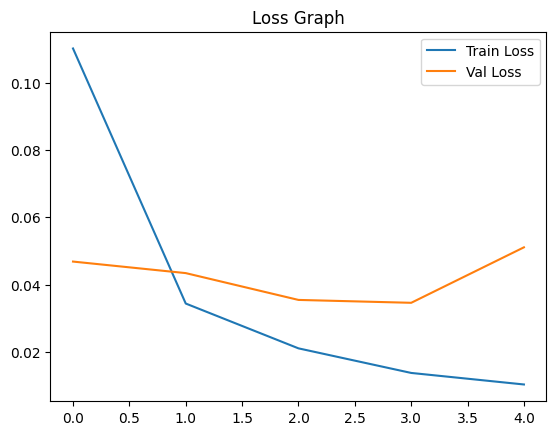

In [15]:
# ================================
# 9. Plot Accuracy & Loss Graph
# ================================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


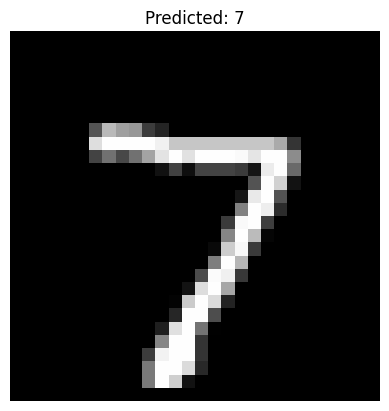

In [16]:
# ================================
# 10. Prediction Example
# ================================
predictions = model.predict(x_test)

plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title("Predicted: " + str(np.argmax(predictions[0])))
plt.axis('off')
plt.show()

In [17]:
# ================================
# 11. Save Model
# ================================
model.save("cnn_mnist_model.h5")

print("Model saved successfully!")

Model saved successfully!
